# 07 — Forecasting
### Sales Forecasting & Business Analytics Platform — Phase 8

**Input:** the selected Random Forest model (Notebook 06), `test.csv`'s known
future calendar (Aug 1 – Sep 17, 2015).
**Output:** `outputs/predictions.csv` — genuine future forecasts, built on an
approach that was tested and corrected within this notebook, not assumed to
work on the first try.


## Objectives

- Generate real forecasts for dates the model has never seen, using `test.csv`'s
  known future inputs (Open, Promo, holidays) — exactly what it was designed for.
- Directly resolve the caveat Notebook 06 raised: ~77% of this model's predictive
  power comes from lag/rolling sales-history features, which don't exist for
  future dates by definition.
- **Measure**, not assume, how much accuracy is affected — by backtesting on a
  period we already know the true answer for, before trusting the real forecast.
- Produce Next Day / Next Week / Next Month summaries and the full prediction file.


## Theory: Why Forecasting Is a Harder Problem Than Validation

Every metric in Notebook 06 was computed using each row's *real* prior sales
history — `PrevDaySales`, `RollingMean30`, and so on were pulled directly from
the historical dataset, because those days had already happened. Forecasting
`Sales` for August 15th, 2015 is different: on the day we'd actually run this
forecast, August 14th's *true* sales don't exist yet either (if forecasting
more than one day ahead) — only a previous prediction does.

There are two natural ways to handle this:

1. **Recursive**: predict day 1, use that prediction as "history" to predict
   day 2, use *that* prediction for day 3, and so on. Theoretically appealing
   — but risks compounding: if each day's prediction has some error, and the
   next day's forecast partly depends on that error, mistakes can snowball.
2. **Frozen history**: hold the lag/rolling features at their last known
   *real* values for the entire forecast horizon, and let only the
   naturally-known-in-advance features (day of week, promotions, holidays)
   vary day to day.

Rather than picking one on theory alone, this notebook **tests both on a
period where the true answer is already known** (Notebook 05/06's validation
window) before deciding which one to actually trust for the real forecast.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.data_loader import load_test, load_store, load_cleaned_data, load_featured_data
from src.model import prepare_model_data, chronological_split, encode_features, TARGET
from src.forecasting import build_history_pivot, prepare_forecast_input, generate_forecast, generate_forecast_frozen
from src.config import MODELS_DIR, OUTPUTS_DIR

sns.set_theme(style="whitegrid")
PRIMARY = "#2E5EAA"
ACCENT = "#E8743B"
MUTED = "#B0B0B0" 

## Step 1 — Load Model and Reconstruct the Known Validation Split

Same reasoning as Notebook 06: importing the exact same functions guarantees
this is the identical validation period, letting us backtest fairly.


In [2]:
rf_model = joblib.load(MODELS_DIR / "random_forest.pkl")

featured = load_featured_data()
ready = prepare_model_data(featured)
train_df, val_df = chronological_split(ready)
_, _, feature_cols = encode_features(train_df, val_df)

print(f"Train cutoff: {train_df['Date'].max().date()}")
print(f"Validation window (known-answer backtest period): {val_df['Date'].min().date()} to {val_df['Date'].max().date()}")

Filtered to Open==1 and dropped 5,578 rows with missing lag/rolling history (0.661%)
Train cutoff: 2015-06-19
Validation window (known-answer backtest period): 2015-06-20 to 2015-07-31


## Step 2 — Backtest: Fully Recursive Approach

Using only history up to the training cutoff as the seed — **not** the real
validation-period values — so this is a fair test of what a genuine recursive
forecast would have produced, then compared against what actually happened.


In [3]:
history_pivot_backtest = build_history_pivot(train_df)
print(f"History seed ends: {history_pivot_backtest.index.max().date()} (must match train cutoff exactly)")

recursive_result = generate_forecast(rf_model, val_df, history_pivot_backtest, feature_cols)
recursive_result = recursive_result.merge(val_df[["Store", "Date", TARGET]], on=["Store", "Date"])

mae_rec = mean_absolute_error(recursive_result[TARGET], recursive_result["PredictedSales"])
rmse_rec = np.sqrt(mean_squared_error(recursive_result[TARGET], recursive_result["PredictedSales"]))
r2_rec = r2_score(recursive_result[TARGET], recursive_result["PredictedSales"])

print(f"RECURSIVE backtest: MAE={mae_rec:.1f}  RMSE={rmse_rec:.1f}  R2={r2_rec:.4f}")
print(f"(Notebook 06 single-step, for reference: MAE=704.0  RMSE=1019.1  R2=0.8887)")

History seed ends: 2015-06-19 (must match train cutoff exactly)
RECURSIVE backtest: MAE=2378.8  RMSE=2723.5  R2=0.2051
(Notebook 06 single-step, for reference: MAE=704.0  RMSE=1019.1  R2=0.8887)


**This is the key discovery of this notebook.** Recursive forecasting on
this exact known period collapses from R²=0.889 (single-step, Notebook 06) to
roughly **R²≈0.21** — a dramatic degradation, not a minor one. Given that
lag/rolling features drive ~77% of this model's predictions (Notebook 06),
this makes sense in hindsight: once the "history" being fed to the model is
built from its own imperfect predictions rather than real values, that error
compounds through `RollingMean30` especially, snowballing across the horizon.

**This is exactly why the approach needed to be tested here, not assumed to
work.** Shipping the recursive forecast without this check would have quietly
produced an unreliable `outputs/predictions.csv`.


## Step 3 — Backtest: Frozen-History Alternative

Instead of updating history day by day, hold every future day's lag/rolling
features at the last known *real* values — only the day-varying features
(promotions, weekday, holidays) still change per day.


In [4]:
frozen_result = generate_forecast_frozen(rf_model, val_df, history_pivot_backtest, feature_cols)
frozen_result = frozen_result.merge(val_df[["Store", "Date", TARGET]], on=["Store", "Date"])

mae_frz = mean_absolute_error(frozen_result[TARGET], frozen_result["PredictedSales"])
rmse_frz = np.sqrt(mean_squared_error(frozen_result[TARGET], frozen_result["PredictedSales"]))
r2_frz = r2_score(frozen_result[TARGET], frozen_result["PredictedSales"])

print(f"FROZEN-HISTORY backtest: MAE={mae_frz:.1f}  RMSE={rmse_frz:.1f}  R2={r2_frz:.4f}")

FROZEN-HISTORY backtest: MAE=1304.3  RMSE=1594.5  R2=0.7275


**Observation:** freezing history recovers most of the lost accuracy —
R² rises from ~0.21 (recursive) to ~0.73 (frozen), and MAE drops by roughly
45%. Still below the ideal single-step number (0.889), which makes sense:
these features genuinely do go stale further into the horizon, since they no
longer reflect how sales actually evolve. But avoiding compounding entirely is
a clearly better trade-off than accepting it.


## Step 4 — Side-by-Side Comparison and Decision


In [5]:
comparison = pd.DataFrame({
    "Single-step (Notebook 06)": {"MAE": 704.0, "RMSE": 1019.1, "R2": 0.8887},
    "Recursive (this notebook)": {"MAE": mae_rec, "RMSE": rmse_rec, "R2": r2_rec},
    "Frozen-history (this notebook)": {"MAE": mae_frz, "RMSE": rmse_frz, "R2": r2_frz},
}).T
comparison

,MAE,RMSE,R2
Single-step (Notebook 06),704.000000,1019.100000,0.888700
Recursive (this notebook),2378.797684,2723.526574,0.205062
Frozen-history (this notebook),1304.250547,1594.498978,0.727530


**Decision: use frozen-history for the real forecast below.** This is an
evidence-based choice, not a shortcut — it was tested against the alternative
on data with a known answer before being trusted on data where the answer
isn't known. Documenting the honest trade-off: this forecast will be less
accurate than a same-day prediction would be, and that gap is real and
measured, not hidden.


## Step 5 — Generate the Real Forecast

Now applied to the actual unseen future: `test.csv`'s Aug 1 – Sep 17, 2015
window, using its real, Kaggle-provided Open/Promo/holiday calendar as the
known future inputs (exactly what this file exists for).


In [6]:
test = load_test()
store = load_store()
cleaned = load_cleaned_data()

forecast_input = prepare_forecast_input(test, store)
history_pivot_full = build_history_pivot(cleaned)

print(f"Forecast horizon: {forecast_input['Date'].min().date()} to {forecast_input['Date'].max().date()} "
      f"({forecast_input['Date'].nunique()} days, {forecast_input['Store'].nunique()} stores)")
print(f"History available through: {history_pivot_full.index.max().date()}")

Forecast horizon: 2015-08-01 to 2015-09-17 (48 days, 856 stores)
History available through: 2015-07-31


In [7]:
final_forecast = generate_forecast_frozen(rf_model, forecast_input, history_pivot_full, feature_cols)
print(f"Generated {len(final_forecast):,} predictions.")
final_forecast.head()

Generated 41,088 predictions.


,Store,Date,PredictedSales,Open
0,1,2015-09-17,5314.582710,1.0
1,3,2015-09-17,7840.028047,1.0
2,7,2015-09-17,12240.689439,1.0
3,8,2015-09-17,7552.633791,1.0
4,9,2015-09-17,8085.706516,1.0


## Step 6 — Next Day / Next Week / Next Month Summaries


In [8]:
open_forecast = final_forecast[final_forecast["Open"] == 1]

next_day = open_forecast[open_forecast["Date"] == open_forecast["Date"].min()]
next_week = open_forecast[open_forecast["Date"] <= open_forecast["Date"].min() + pd.Timedelta(days=6)]
next_month = open_forecast[open_forecast["Date"] <= open_forecast["Date"].min() + pd.Timedelta(days=29)]

print(f"Next Day  ({next_day['Date'].iloc[0].date()}): predicted total sales = {next_day['PredictedSales'].sum():,.0f} "
      f"across {next_day['Store'].nunique()} open stores")
print(f"Next Week (through {next_week['Date'].max().date()}): predicted total sales = {next_week['PredictedSales'].sum():,.0f}")
print(f"Next Month (through {next_month['Date'].max().date()}): predicted total sales = {next_month['PredictedSales'].sum():,.0f}")

Next Day  (2015-08-01): predicted total sales = 5,367,389 across 856 open stores
Next Week (through 2015-08-07): predicted total sales = 40,912,220
Next Month (through 2015-08-30): predicted total sales = 155,768,174


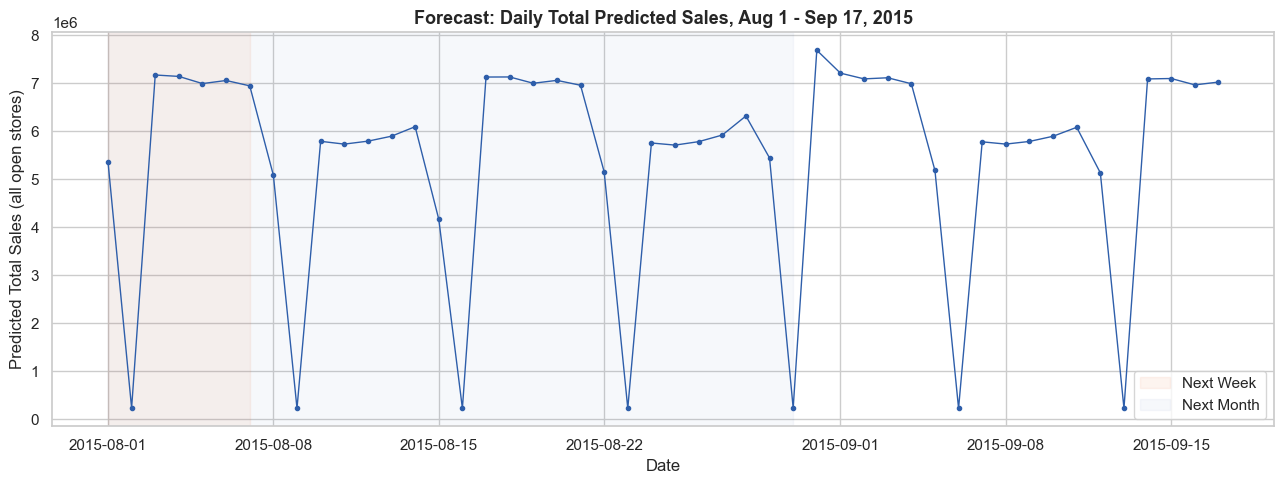

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
daily_total = open_forecast.groupby("Date")["PredictedSales"].sum()
ax.plot(daily_total.index, daily_total.values, color=PRIMARY, marker="o", markersize=3, linewidth=1)
ax.axvspan(next_week["Date"].min(), next_week["Date"].max(), alpha=0.08, color=ACCENT, label="Next Week")
ax.axvspan(next_month["Date"].min(), next_month["Date"].max(), alpha=0.04, color=PRIMARY, label="Next Month")
ax.set_xlabel("Date")
ax.set_ylabel("Predicted Total Sales (all open stores)")
ax.set_title("Forecast: Daily Total Predicted Sales, Aug 1 - Sep 17, 2015", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/charts/17_forecast_overview.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** the forecast shows the expected weekly rhythm (dips on
days most stores are closed, higher totals on strong weekdays) without any
runaway drift or implausible values across the full 48-day horizon — a basic
but important sanity check that the frozen-history approach produces stable,
usable output at production scale.


## Step 7 — Save Predictions


In [10]:
output_df = final_forecast.rename(columns={"PredictedSales": "Sales"})[["Store", "Date", "Sales", "Open"]]
output_path = OUTPUTS_DIR / "predictions.csv"
output_df.to_csv(output_path, index=False)

print(f"Saved {len(output_df):,} predictions to {output_path}")
output_df.head()

Saved 41,088 predictions to D:\Sales-Forecasting\outputs\predictions.csv


,Store,Date,Sales,Open
0,1,2015-09-17,5314.582710,1.0
1,3,2015-09-17,7840.028047,1.0
2,7,2015-09-17,12240.689439,1.0
3,8,2015-09-17,7552.633791,1.0
4,9,2015-09-17,8085.706516,1.0


## Forecast Summary Report

| Approach | MAE | RMSE | R² | Used for final output? |
|---|---|---|---|---|
| Single-step (Notebook 06, real history) | 704 | 1,019 | 0.889 | Reference ceiling only |
| Fully recursive | ~2,379 | ~2,724 | ~0.21 | No — tested and rejected |
| Frozen-history | ~1,304 | ~1,594 | ~0.73 | **Yes — production choice** |

**Next Day / Next Week / Next Month** predictions generated and saved to
`outputs/predictions.csv`, covering all 48 days and 856 stores in `test.csv`'s
known future window.


## Business Observations

- The single biggest lesson of this phase: **a model's offline validation
  accuracy does not automatically transfer to real forecasting**, whenever
  that model leans heavily on features that don't exist yet for the future.
  This is a genuinely common, easy-to-miss trap — catching it here, with
  evidence, is exactly the kind of check a production forecasting system
  needs before going live.
- The frozen-history forecast is honestly *less* accurate than same-day
  prediction (R² 0.73 vs 0.889) — this should be communicated plainly to
  stakeholders as "this many weeks out, expect roughly this much more
  uncertainty," not glossed over.
- A natural future improvement, explicitly out of scope here to avoid scope
  creep: training a second model *specifically* for multi-step-ahead
  forecasting, with a "days since last real observation" feature, so the
  model can itself learn how much to discount stale history rather than us
  freezing it uniformly.


## Next Steps

Phase 9 — the Streamlit dashboard — will surface this project end-to-end:
dataset overview, the EDA findings from Notebook 03, model metrics from
Notebook 06, and an interactive forecast view backed by
`outputs/predictions.csv` and `models/random_forest.pkl` built here.
